# ¿Se puede confiar en la ciencia social?

**600 papers. 62 revistas. Una pregunta incómoda: si alguien repite tu análisis con tus propios datos, ¿sale lo mismo?**

---

📄 **Paper:** Breznau, N. et al. (2026). *Investigating the reproducibility of the social and behavioural sciences.* Nature.
DOI: [10.1038/s41586-026-10203-5](https://doi.org//10.1038/s41586-026-10203-5)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-04-reproducibilidad-ciencias-sociales/notebook.ipynb)

🎬 **Video:** [Pendiente]

## El experimento

El proyecto SCORE eligió 600 papers al azar (pero balanceando por campo) publicados entre 2009 y 2018 en 62 revistas de ciencias sociales y del comportamiento: psicología, economía, ciencia política, sociología, educación, marketing y más.

La idea es simple: pedirle a alguien que repita el análisis del paper con los mismos datos. Si sale lo mismo, es reproducible. Si no... hay un problema.

De los 600, el paper evaluó 143 papers (el repositorio OSF expandido, que se sigue actualizando, llega a 165). El resto no compartió los datos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_PRECISO = 0       # Diferencia exacta (0%) para "precisamente reproducible"
UMBRAL_APROXIMADO = 15   # Dentro del 15% del efecto original
UMBRAL_P = 0.05          # Diferencia máxima de p-value para "aproximado"
FUENTE = 'Fuente: Breznau et al. (2026), Nature | Datos: OSF (doi.org/10.17605/osf.io/ed8pj)'
COLOR_PRECISO = '#2563EB'
COLOR_APROXIMADO = '#059669'
COLOR_NO_REPRO = '#DC2626'
COLOR_REFERENCIA = '#D97706'

# ── Imports ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os, urllib.request

# ── Estilo CaM ──
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

# ── Datos ──
BASE_URL = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-04-04-reproducibilidad-ciencias-sociales/datos'
DATA_DIR = 'datos'

if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR, exist_ok=True)
    for f in ['reproducibilidad_por_campo.csv', 'reproducibilidad_por_anio.csv',
              'disponibilidad_datos.csv', 'diferencias_p_values.csv',
              'politicas_revistas.csv', 'resumen_global.csv']:
        urllib.request.urlretrieve(f'{BASE_URL}/{f}', f'{DATA_DIR}/{f}')

campos = pd.read_csv(f'{DATA_DIR}/reproducibilidad_por_campo.csv')
anios = pd.read_csv(f'{DATA_DIR}/reproducibilidad_por_anio.csv')
disponibilidad = pd.read_csv(f'{DATA_DIR}/disponibilidad_datos.csv')
pvalues = pd.read_csv(f'{DATA_DIR}/diferencias_p_values.csv')
revistas = pd.read_csv(f'{DATA_DIR}/politicas_revistas.csv')
resumen = pd.read_csv(f'{DATA_DIR}/resumen_global.csv')

r = resumen.iloc[0]
print(f"Muestra: {int(r['papers_muestra'])} papers de {int(r['revistas'])} revistas (2009–2018)")
print(f"Evaluados: {int(r['papers_evaluados'])} papers, {int(r['claims_evaluados'])} claims")
print(f"Precisamente reproducible: {r['preciso_pct_ponderado']}% (ponderado)")
print(f"Al menos aproximadamente: {r['aproximado_mas_pct_ponderado']}% (ponderado)")
print(f"Datos disponibles online: {r['datos_disponibles_pct']}%")

Muestra: 600 papers de 62 revistas (2009–2018)
Evaluados: 165 papers, 573 claims
Precisamente reproducible: 55.5% (ponderado)
Al menos aproximadamente: 77.6% (ponderado)
Datos disponibles online: 19.6%


## ¿Cuántos papers sobreviven la prueba?

Aquí está.

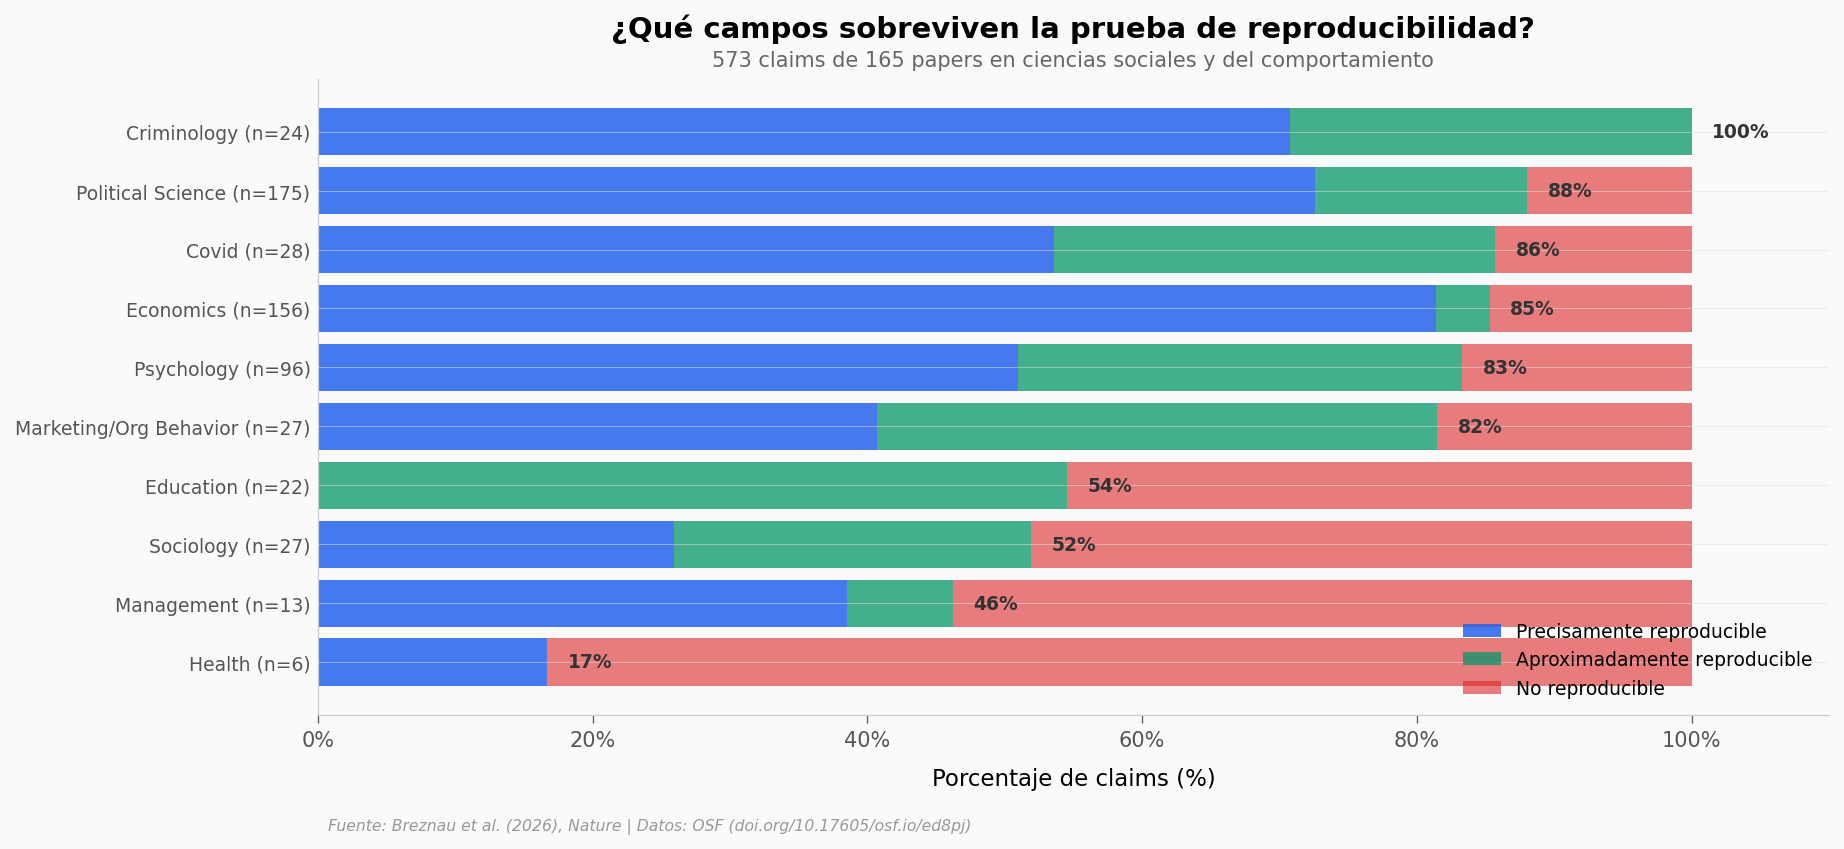

In [2]:
# ── Gráfica hero: reproducibilidad por campo ──
fig, ax = plt.subplots(figsize=(13, 5.5))

# Ordenar por approx+ descendente
df = campos.sort_values('aproximado_mas_pct', ascending=True).copy()
y_pos = range(len(df))

# Barras apiladas horizontales
bars_precise = ax.barh(y_pos, df['preciso_pct'], color=COLOR_PRECISO, alpha=0.85, label='Precisamente reproducible')
bars_approx = ax.barh(y_pos, df['aproximado_mas_pct'] - df['preciso_pct'], left=df['preciso_pct'],
                       color=COLOR_APROXIMADO, alpha=0.75, label='Aproximadamente reproducible')
bars_not = ax.barh(y_pos, df['no_reproducible_pct'], left=df['aproximado_mas_pct'],
                    color=COLOR_NO_REPRO, alpha=0.6, label='No reproducible')

# Etiquetas de campo con n
labels = [f"{row['campo'].title()} (n={int(row['n_claims'])})" for _, row in df.iterrows()]
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)

# Inline labels: porcentaje approx+ a la derecha
for i, (_, row) in enumerate(df.iterrows()):
    ax.text(row['aproximado_mas_pct'] + 1.5, i, f"{row['aproximado_mas_pct']:.0f}%",
            va='center', fontsize=9, fontweight='bold', color='#333333')

ax.set_xlim(0, 110)
ax.set_xlabel('Porcentaje de claims (%)', fontsize=11)
ax.set_title('¿Qué campos sobreviven la prueba de reproducibilidad?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'{int(r["claims_evaluados"])} claims de {int(r["papers_evaluados"])} papers en ciencias sociales y del comportamiento',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(fontsize=9, loc='lower right', framealpha=0.9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/reproducibilidad_por_campo.png', dpi=200, bbox_inches='tight')
plt.show()

Criminología logra un 100% de reproducibilidad aproximada (con solo 24 claims, ojo). Psicología y COVID superan el 78%. En el otro extremo, salud (16,7%) y gestión (46,2%) son los campos con peor reproducibilidad.

Pero la gráfica más reveladora no es esta. Es la siguiente: ¿cuántos papers te dejan ver los datos?

## El verdadero cuello de botella

El paper reporta que **solo el 24% de sus 600 papers compartió datos.** En el repositorio OSF expandido (700 papers), la cifra baja a 19,6%. Solo el 16,3% compartió código. Sin datos, no hay reproducibilidad posible — no importa qué tan bien esté escrito el paper.

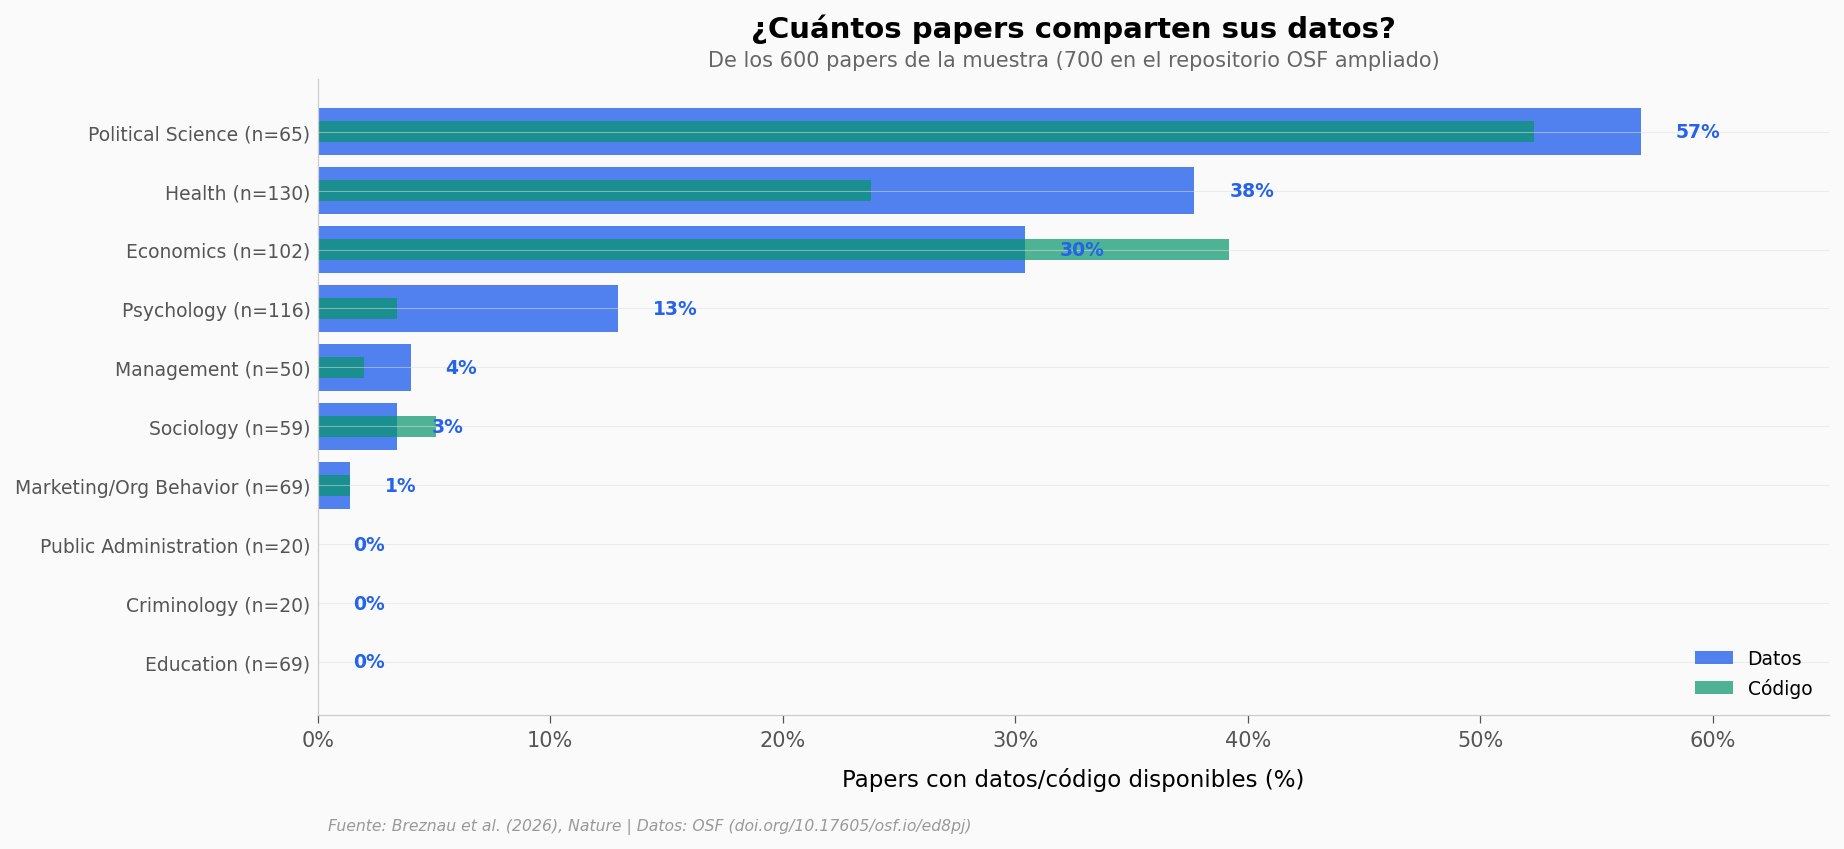

In [3]:
# ── Disponibilidad de datos por disciplina ──
fig, ax = plt.subplots(figsize=(13, 5.5))

df = disponibilidad.sort_values('datos_disponibles_pct', ascending=True).copy()
y_pos = range(len(df))

bars = ax.barh(y_pos, df['datos_disponibles_pct'], color=COLOR_PRECISO, alpha=0.8, label='Datos')
bars2 = ax.barh(y_pos, df['codigo_disponible_pct'], color=COLOR_APROXIMADO, alpha=0.7,
                left=0, height=0.35, label='Código')

labels = [f"{row['disciplina'].title()} (n={int(row['n_papers'])})" for _, row in df.iterrows()]
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)

for i, (_, row) in enumerate(df.iterrows()):
    ax.text(row['datos_disponibles_pct'] + 1.5, i, f"{row['datos_disponibles_pct']:.0f}%",
            va='center', fontsize=9, fontweight='bold', color=COLOR_PRECISO)

ax.set_xlim(0, 65)
ax.set_xlabel('Papers con datos/código disponibles (%)', fontsize=11)
ax.set_title('¿Cuántos papers comparten sus datos?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'De los 600 papers de la muestra (700 en el repositorio OSF ampliado)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(fontsize=9, loc='lower right', framealpha=0.9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/disponibilidad_datos.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Estamos mejorando?

El paper reporta que los papers más recientes son más reproducibles, pero usando un modelo ajustado por múltiples variables. Veamos qué dicen las medias crudas año a año.

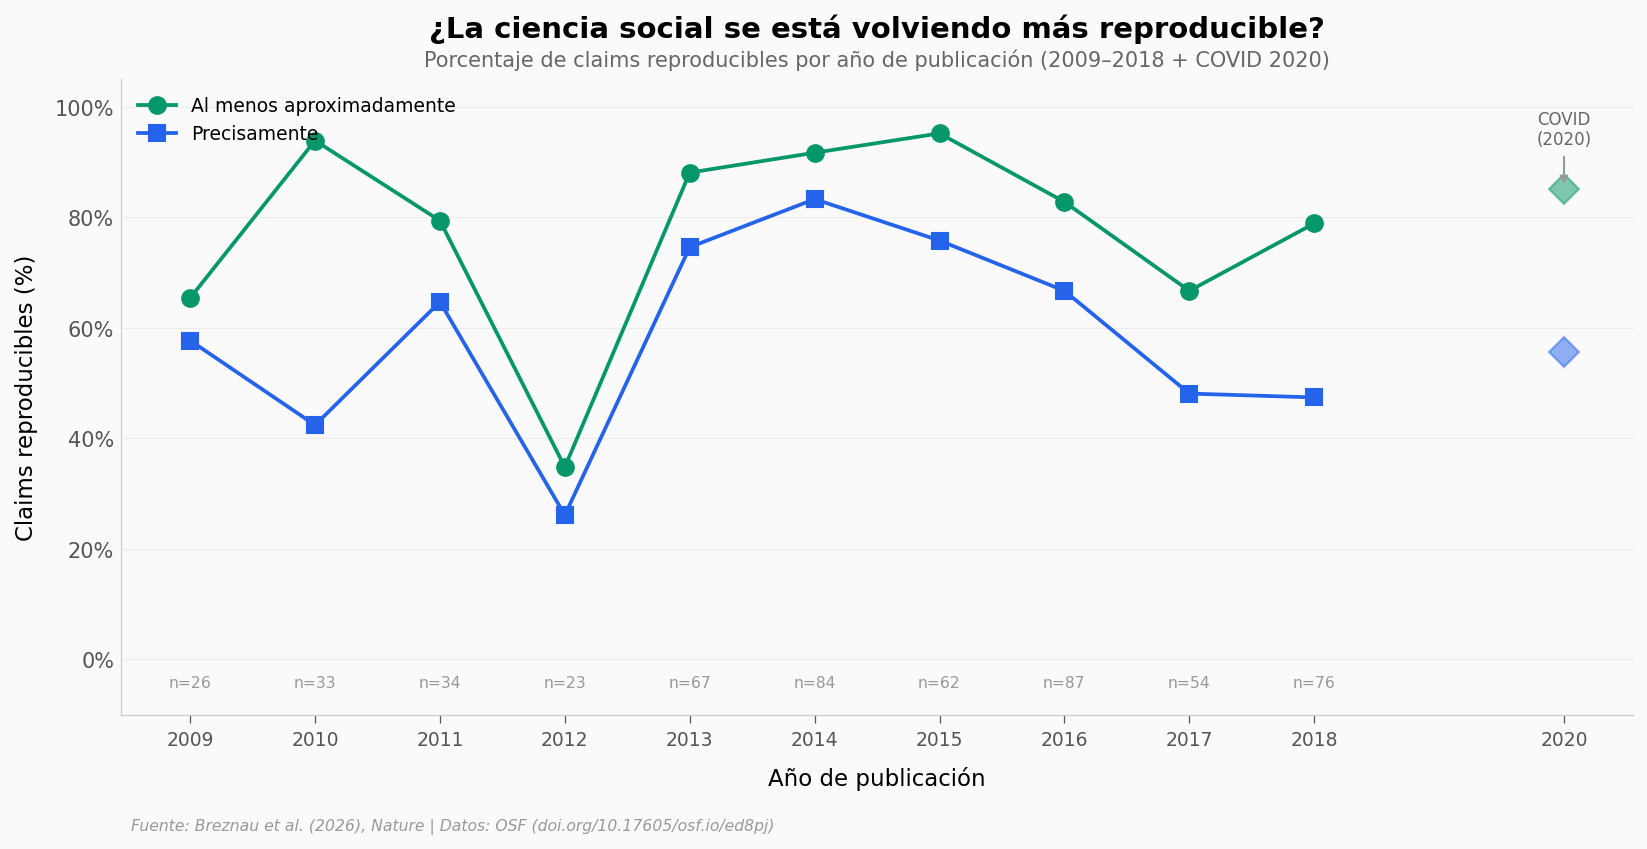

In [4]:
# ── Tendencia temporal de reproducibilidad ──
fig, ax = plt.subplots(figsize=(13, 5.5))

df = anios.copy()
# Separar 2020 (COVID batch, no es la serie regular)
df_regular = df[df['anio'] <= 2018]
df_covid = df[df['anio'] == 2020]

# Líneas principales
ax.plot(df_regular['anio'], df_regular['aproximado_mas_pct'], 'o-',
        color=COLOR_APROXIMADO, markersize=8, label='Al menos aproximadamente')
ax.plot(df_regular['anio'], df_regular['preciso_pct'], 's-',
        color=COLOR_PRECISO, markersize=8, label='Precisamente')

# COVID batch como punto separado
if len(df_covid) > 0:
    ax.plot(df_covid['anio'], df_covid['aproximado_mas_pct'], 'D',
            color=COLOR_APROXIMADO, markersize=10, alpha=0.5)
    ax.plot(df_covid['anio'], df_covid['preciso_pct'], 'D',
            color=COLOR_PRECISO, markersize=10, alpha=0.5)
    ax.annotate('COVID\n(2020)', xy=(2020, df_covid['aproximado_mas_pct'].iloc[0]),
                xytext=(2020, df_covid['aproximado_mas_pct'].iloc[0] + 8),
                fontsize=8, color='#666666', ha='center',
                arrowprops=dict(arrowstyle='->', color='#999999', lw=1))

# Tamaño de muestra debajo de cada punto
for _, row in df_regular.iterrows():
    ax.text(row['anio'], -5, f"n={int(row['n_claims'])}",
            ha='center', fontsize=7.5, color='#999999')

ax.set_xlabel('Año de publicación', fontsize=11)
ax.set_ylabel('Claims reproducibles (%)', fontsize=11)
ax.set_title('¿La ciencia social se está volviendo más reproducible?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Porcentaje de claims reproducibles por año de publicación (2009–2018 + COVID 2020)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_ylim(-10, 105)
ax.set_xticks(list(range(2009, 2019)) + [2020])
ax.set_xticklabels([str(y) for y in range(2009, 2019)] + ['2020'], fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tendencia_temporal.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan cerca quedan los p-values?

Cuando un resultado se reproduce, ¿el p-value queda exactamente igual? De 421 claims con p-values comparables, la mediana de la diferencia es de solo 0,0039 — prácticamente cero. El 93,8% queda dentro de ±0,05 del original.

Pero lo interesante está en la cola: los que no se reproducen.

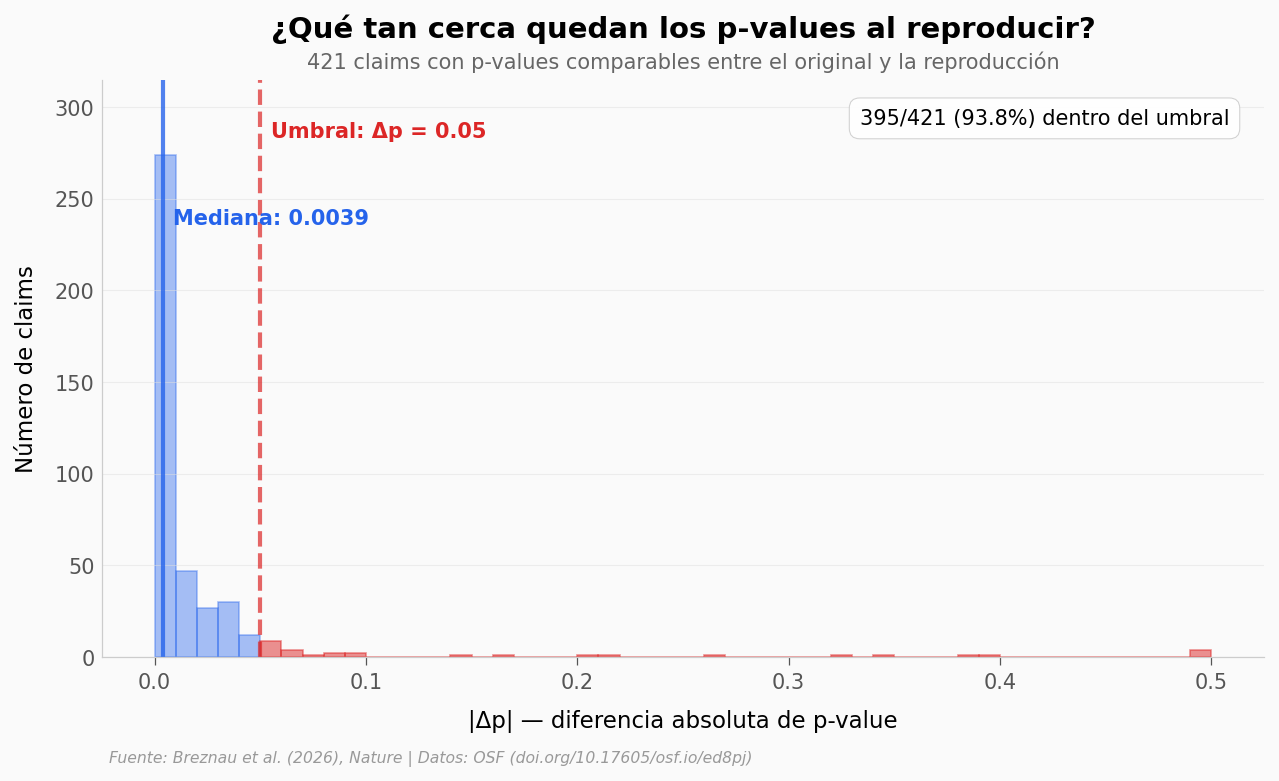

In [5]:
# ── Distribución de diferencias de p-value ──
fig, ax = plt.subplots(figsize=(10, 5))

diffs = pvalues['abs_diff_p'].values
# Cap at 0.5 for visualization (few outliers beyond)
diffs_capped = np.clip(diffs, 0, 0.5)

n, bins, patches = ax.hist(diffs_capped, bins=50, color=COLOR_PRECISO, alpha=0.4,
                            edgecolor=COLOR_PRECISO, linewidth=0.8)

# Color patches beyond threshold
for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge >= UMBRAL_P:
        patch.set_facecolor(COLOR_NO_REPRO)
        patch.set_alpha(0.5)
        patch.set_edgecolor(COLOR_NO_REPRO)

# Reference line at threshold
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)
ax.axvline(x=UMBRAL_P, color=COLOR_NO_REPRO, linewidth=2, linestyle='--', alpha=0.7)
ax.text(UMBRAL_P + 0.005, y_max * 0.9, f'Umbral: Δp = {UMBRAL_P}',
        fontsize=10, color=COLOR_NO_REPRO, fontweight='bold')

# Median
median_diff = np.median(diffs)
ax.axvline(x=median_diff, color=COLOR_PRECISO, linewidth=2, alpha=0.8)
ax.text(median_diff + 0.005, y_max * 0.75, f'Mediana: {median_diff:.4f}',
        fontsize=10, color=COLOR_PRECISO, fontweight='bold')

# Stats annotation
within = (diffs <= UMBRAL_P).sum()
total = len(diffs)
ax.text(0.97, 0.95, f'{within}/{total} ({within/total*100:.1f}%) dentro del umbral',
        transform=ax.transAxes, fontsize=10, ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#cccccc', alpha=0.9))

ax.set_xlabel('|Δp| — diferencia absoluta de p-value', fontsize=11)
ax.set_ylabel('Número de claims', fontsize=11)
ax.set_title('¿Qué tan cerca quedan los p-values al reproducir?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'{total} claims con p-values comparables entre el original y la reproducción',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/diferencias_p_values.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| ~55% de los papers son precisamente reproducibles (ponderado) | ✅ | 55,5% en nuestros datos vs 53,6% del paper (CI 45,8–60,7%). La diferencia se explica porque el repositorio OSF tiene 165 papers evaluados vs 143 del paper (living repository con adiciones post-publicación) |
| ~78% son al menos aproximadamente reproducibles | ✅ | 77,6% vs 73,5% del paper (CI 66,4–80,0%). Consistente |
| Solo ~24% de los papers comparten datos | ✅ | El paper reporta 24,0% (144/600). En el repositorio OSF expandido (700 papers): 19,6% (137/700). La diferencia se debe a que el OSF incluye papers adicionales post-publicación |
| El 93,8% de los p-values reproducidos caen dentro de ±0,05 del original | ✅ | 395/421 claims. Mediana |Δp| = 0,0039 |
| Los papers más recientes son más reproducibles | ⚠️ | La tendencia no es lineal: 2012 (34,8% approx+) y 2017 (66,7%) son los años más bajos de la serie 2010–2018. El paper observa la tendencia usando un modelo ajustado, no medias crudas |
| Ciencia política y economía son más reproducibles que otros campos | ✅ | En nuestros datos (approx+): ciencia política (88,0%) y economía (85,3%) superan a psicología (83,3%), consistente con el paper |

> **Limitaciones:** (1) El repositorio OSF es "living" — incluye más papers que los 143 del análisis publicado, lo que puede alterar porcentajes. (2) Los claims no son independientes: un paper con 10 claims pesa 10× más que uno con 1 sin ponderación inversa. (3) Las muestras por campo son desiguales (n=5 en salud vs n=89 en psicología). (4) Los datos COVID (2020) no son directamente comparables con la serie 2009-2018.

## Ahora tú

1. **¿Influye la política de la revista?** De las 62 revistas, 32 exigen compartir datos. ¿Los papers de revistas con política de datos son más reproducibles? Prueba filtrando por `require_data` en el CSV de políticas y cruzando con reproducibilidad.

2. **¿Los efectos grandes se reproducen mejor?** El CSV de p-values tiene columna `preciso`. ¿La diferencia de p-value es menor para los que fueron clasificados como precisos?

3. **¿Qué pasa si cambias el umbral?** Prueba cambiar `UMBRAL_P` a 0.01 o 0.10. ¿Cómo cambia la proporción de "aproximadamente reproducibles"?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Los papers clasificados como "precisos" tienen diferencias de p-value más pequeñas?

precisos = pvalues[pvalues['preciso'] == True]['abs_diff_p']
no_precisos = pvalues[pvalues['preciso'] == False]['abs_diff_p']

print(f"Clasificados como precisos:  n={len(precisos)}, mediana |Δp| = {precisos.median():.4f}")
print(f"No precisos:                 n={len(no_precisos)}, mediana |Δp| = {no_precisos.median():.4f}")
print(f"\nRatio: los no precisos se desvían {no_precisos.median()/max(precisos.median(), 0.0001):.1f}× más")
print(f"\n¿Qué porcentaje de cada grupo cae dentro de ±{UMBRAL_P}?")
print(f"  Precisos:    {(precisos <= UMBRAL_P).mean()*100:.1f}%")
print(f"  No precisos: {(no_precisos <= UMBRAL_P).mean()*100:.1f}%")

Clasificados como precisos:  n=255, mediana |Δp| = 0.0030
No precisos:                 n=166, mediana |Δp| = 0.0042

Ratio: los no precisos se desvían 1.4× más

¿Qué porcentaje de cada grupo cae dentro de ±0.05?
  Precisos:    99.6%
  No precisos: 84.9%


---

### Créditos

- **Paper:** Breznau, N. et al. (2026). *Investigating the reproducibility of the social and behavioural sciences.* Nature. DOI: [10.1038/s41586-026-10203-5](https://doi.org/10.1038/s41586-026-10203-5)
- **Datos:** [OSF — Materials for SCORE](https://doi.org/10.17605/osf.io/ed8pj) (MIT License)
- **Notebook:** [Ciencia a Mordiscos — El Lab](https://cienciaamordiscos.com)
- **Repo:** [GitHub](https://github.com/Ciencia-a-Mordiscos/lab)